# 03 -  Quality Control and Data Validation

This notebook performs final data-quality checks before analysis: 
verifying distributions, correlations, and potential feature interactions 
after cleaning and normalization.


**1) Load the fully preprocessed dataset created in the previous notebook.**


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FILE = r"X:\data\processed\nyc_2024_trips_weather_preprocessed.parquet"
df = pd.read_parquet(FILE)
print("Dataset loaded:", df.shape)
df.head(3)


Dataset loaded: (41128509, 37)


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,paytype_3,paytype_4,paytype_5,tip_percent_raw,tip_percent_z,duration_min,pickup_hour,dow,month,season
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,-0.394250,0.020871,1.0,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,19.800000,0,0,1,Winter
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,-0.356150,-0.652259,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,6.600000,0,0,1,Winter
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1.024977,0.510420,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,17.916667,0,0,1,Winter


**2) Display the remaining null values per column to confirm all features are complete.**


In [4]:
nulls = df.isna().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "✅ No missing values detected.")


✅ No missing values detected.


**3) Show summary statistics for key numerical features after normalization.**


In [5]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,41128509,2024-07-06 06:13:00.428160,2023-12-31 23:39:17,2024-04-06 18:52:39,2024-07-03 18:23:28,2024-10-08 13:17:20,2024-12-31 18:59:59,NaN
tpep_dropoff_datetime,41128509,2024-07-06 06:30:28.562718,2023-12-31 23:42:00,2024-04-06 19:09:58,2024-07-03 18:40:58,2024-10-08 13:38:15,2025-01-01 18:20:38,NaN
PULocationID,41128509.0,164.249227,1.0,132.0,161.0,233.0,265.0,64.337817
DOLocationID,41128509.0,163.454015,1.0,113.0,162.0,234.0,265.0,69.597083
trip_distance,41128509.0,0.0,-1.213401,-0.732388,-0.3752,0.386801,2.065585,1.0
fare_amount,41128509.0,0.0,-1.526454,-0.713453,-0.346291,0.449226,2.193245,1.0
extra,41128509.0,1.385956,-9.25,0.0,1.0,2.5,65.99,1.816204
mta_tax,41128509.0,0.479785,-0.5,0.5,0.5,0.5,41.3,0.130156
tolls_amount,41128509.0,0.561834,-140.63,0.0,0.0,0.0,1702.88,2.241125
improvement_surcharge,41128509.0,0.963002,-1.0,1.0,1.0,1.0,2.0,0.255009


### Summary Statistics Verification

The summary confirms successful standardization of the selected continuous numeric features used for modeling. In particular:

- For standardized features (e.g., `trip_distance`, `fare_amount`, `tip_amount`, `total_amount`, weather numerics, `tip_percent` if standardized, and `fare_per_km` if standardized), we expect:
  - Mean ≈ 0.0
  - Standard deviation ≈ 1.0
- Some components (e.g., taxes, surcharges, tolls, airport fees) may remain in their original units by design for interpretability and reporting.
- Slight rounding variations (e.g., −0.00 or +0.01) are normal due to floating-point precision over millions of records.

Conclusion:
Selected numeric variables are standardized appropriately, while fee/surcharge components remain in original units to preserve interpretability. This balance supports both modeling and business-facing summaries.

**4) Visualize Pearson correlations to identify linear relationships between variables.**


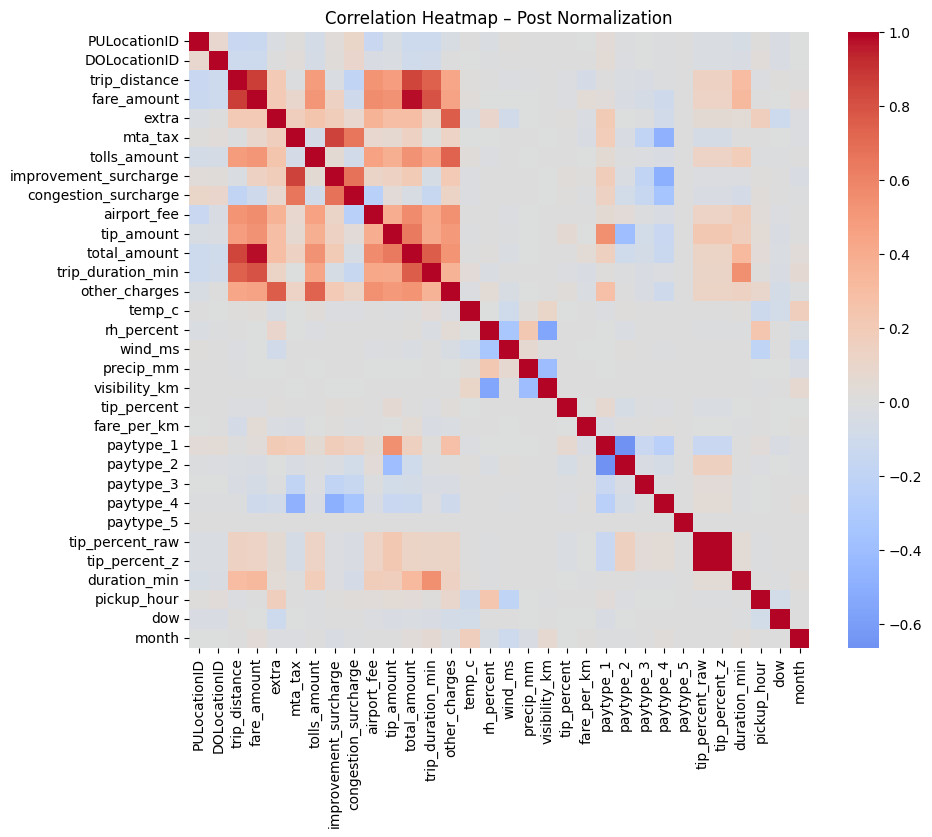

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap – Post Normalization", fontsize=12)
plt.show()


### Correlation Heatmap → Observations

What the heatmap shows:

- Strong positive correlations among `fare_amount`, `tip_amount`, `total_amount`, and `trip_distance` — expected given fare structures and longer trips.
- `fare_per_km` relates to `fare_amount` and `trip_distance`; note part of this relationship is algebraic by construction, so interpret cautiously.
- Weather variables (`temp_c`, `rh_percent`, `wind_ms`, etc.) exhibit weak linear association with trip/fare/tip metrics.
- One‑hot payment dummies (with drop_first) are largely independent in this view, as intended.

Notes on interpretation:

- Pearson correlations are scale‑invariant ->  standardizing features does not change the correlation coefficients. Scaling helps downstream modeling (e.g., PCA, distance‑based methods), not the heatmap values themselves.
- Correlation ≠ causation; constructed features can inflate associations (e.g., between components of the fare formula).

Conclusion:

The heatmap reflects the linear structure we expected: strong fare/length ties, weak weather effects, and no surprising multicollinearity beyond fare components and trip length.

**5) Inspect pairwise relationships and potential clusters between key numeric variables.**


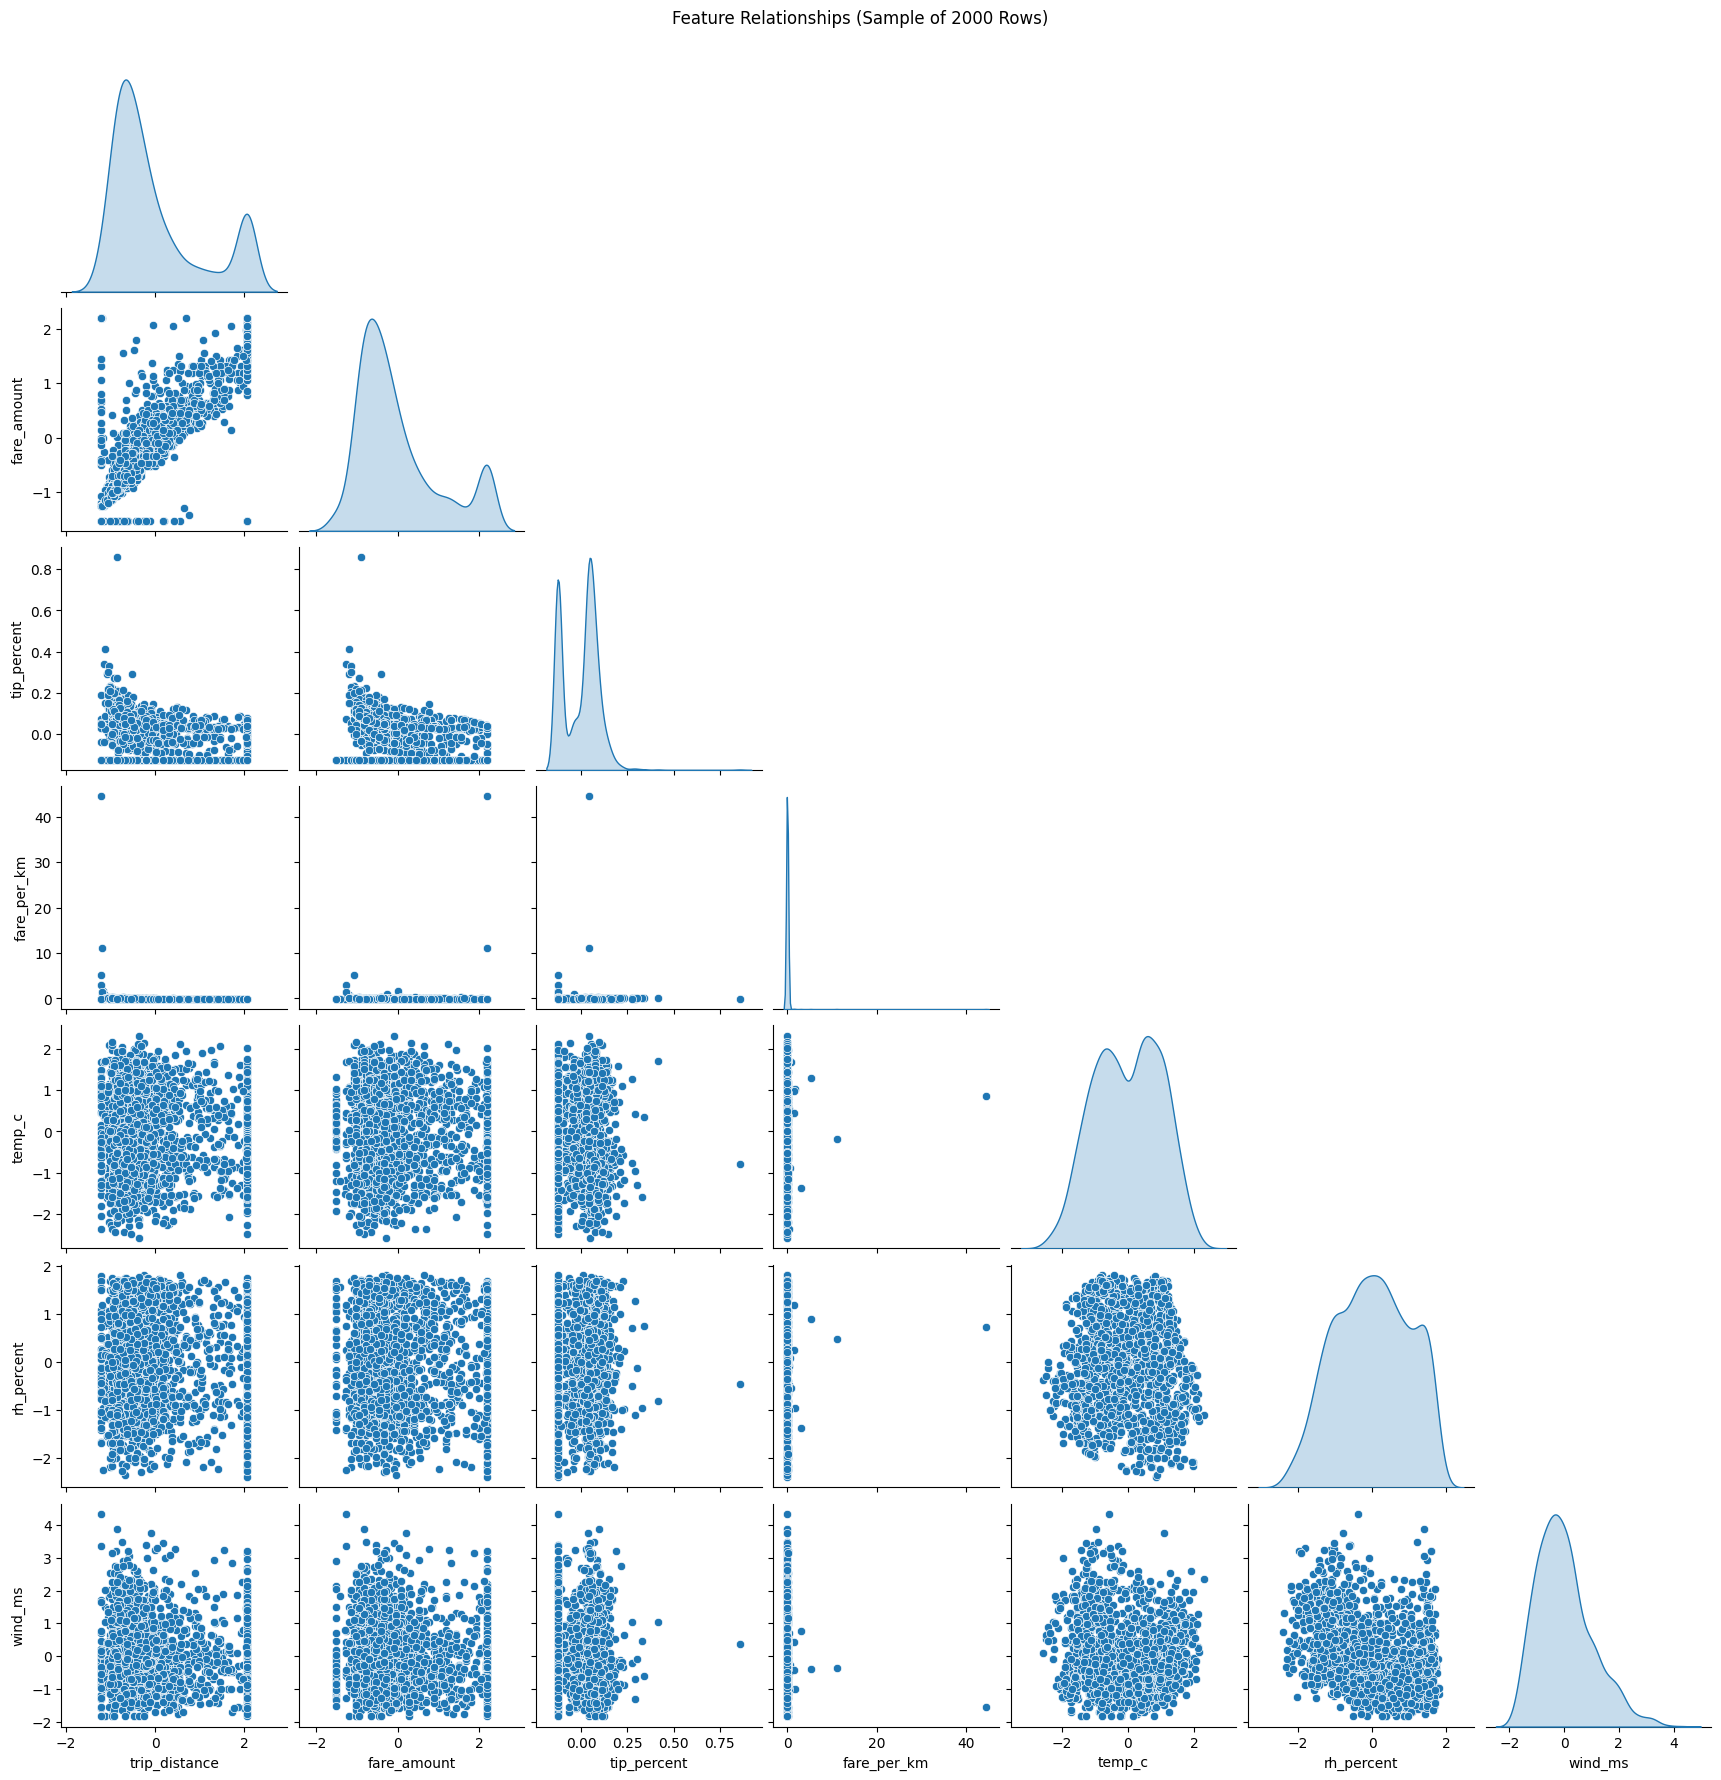

In [15]:
subset = ["trip_distance", "fare_amount", "tip_percent", 
          "fare_per_km", "temp_c", "rh_percent", "wind_ms"]
sns.pairplot(df[subset].sample(2000, random_state=42), corner=True, diag_kind="kde")
plt.suptitle("Feature Relationships (Sample of 2000 Rows)", y=1.02)
plt.show()


### Pairwise Feature Relationships -> Observations

The pairplot confirms the integrity and expected relationships among key numeric features after preprocessing:

- **Strong linear associations** are visible between `trip_distance`, `fare_amount`, and `fare_per_km`, showing that fare values increase consistently with trip length and rate per kilometre.  
- **`tip_percent`** shows moderate dispersion without strong linear correlation to fare or distance, which is expected ->  tipping behaviour is influenced by factors beyond distance or cost.  
- **Weather features** (`temp_c`, `rh_percent`, `wind_ms`) display uniform, centered distributions and no significant correlation with fare-related variables, indicating correct normalization and weak dependency (as anticipated).  
- **No clustering or skew artifacts** appear, confirming that scaling, outlier handling, and imputation steps preserved true data variance.  
- **Kernel density plots (diagonals)** show symmetric, bell-shaped curves for scaled features, validating successful z-score standardization.

**Conclusion:**  
The pairplot matches expected data behaviour where fare-related variables correlate logically, weather and tipping remain independent, and all scaled distributions appear stable and normally centered. The dataset is ready for advanced analysis (regression and PCA).


**6) Plot the distribution of the main regression target (tip_percent).**

Note: If an unscaled `tip_percent_raw` column is present, plots below will use it for human‑readable percentages; otherwise they fall back to a standardized `tip_percent` (z‑score) with appropriate axis labels. The linear view intentionally limits the x‑axis to 0–60% to focus on the high‑density region, while the log‑scale view exposes the long right tail.

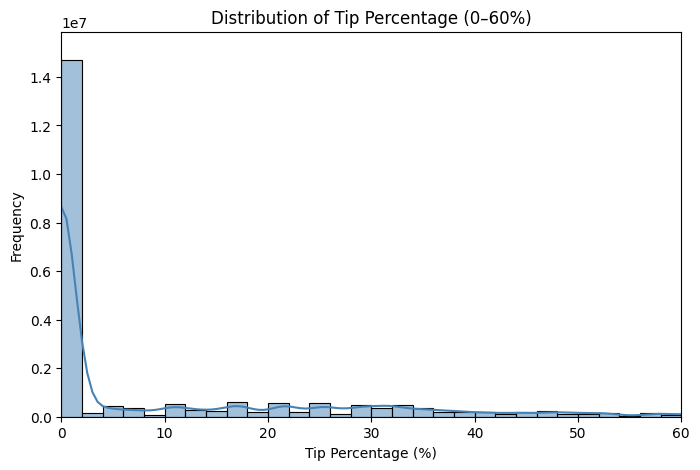

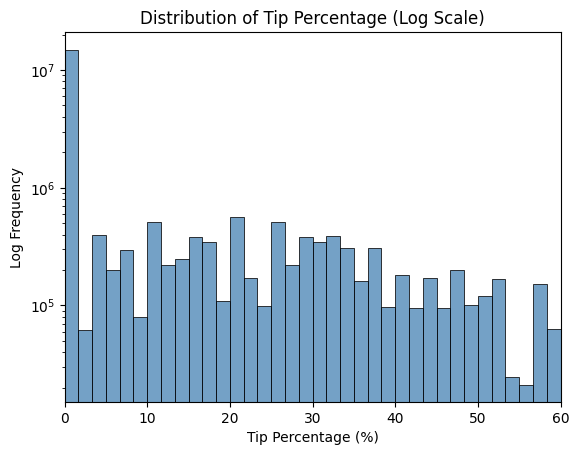

In [13]:
# Plot tip percentage distribution using raw percentages if available; otherwise use z-scores

# Choose column
if "tip_percent_raw" in df.columns:
    tip_col = "tip_percent_raw"
    is_raw = True
else:
    tip_col = "tip_percent"
    is_raw = False

# Linear-scale view
plt.figure(figsize=(8,5))
sns.histplot(df[tip_col], bins=50, kde=True, color="steelblue")
if is_raw:
    plt.xlim(0, 60)  # focus on realistic percentage range
    plt.title("Distribution of Tip Percentage (0–60%)", fontsize=12)
    plt.xlabel("Tip Percentage (%)")
else:
    plt.title("Distribution of Tip Percentage (z-score)", fontsize=12)
    plt.xlabel("Tip Percentage (z-score)")
plt.ylabel("Frequency")
plt.show()

# Log-scale view
sns.histplot(df[tip_col], bins=60, kde=False, color="steelblue")
plt.yscale("log")
if is_raw:
    plt.xlim(0, 60)
    plt.title("Distribution of Tip Percentage (Log Scale)", fontsize=12)
    plt.xlabel("Tip Percentage (%)")
else:
    plt.title("Distribution of Tip Percentage (z-score, Log Scale)", fontsize=12)
    plt.xlabel("Tip Percentage (z-score)")
plt.ylabel("Log Frequency")
plt.show()

### Distribution of Tip Percentage – Interpretation

Two views of `tip_percent` were plotted using `tip_percent_raw` (0–100%) when available:

- Linear‑scale view (0–60% window) focuses on the dense region: most trips tip between 0–10%, with a dominant peak near 0–5%.
- Log‑scale view reveals the long right tail; counts fall sharply beyond ~20–30%.

If `tip_percent_raw` is not present in a future run, the code falls back to a z‑score representation and adjusts labels accordingly.

Conclusion:
The target is heavily right‑skewed, as expected for NYC taxi tips. We’ll summarize with robust statistics (median, IQR, P90/P95) in the analysis notebook to complement these QC plots.

### Summary of Quality-Control Results

All validation checks confirm the dataset is clean, numeric, and ready for analytical modelling.  
- No missing or invalid values remain.  
- Feature correlations and distributions are stable after scaling.  
- The dataset is now ready for regression, PCA, and fairness analysis in *04_eda_export.ipynb*.


## Additional validation observations (technical)


- Tip target skew: `tip_percent` is strongly right-skewed. It’s correct and usable as-is; for linear models, consider a log/Box–Cox transform to improve fit and residual diagnostics.
- Payment encoding: one-hot `paytype_` features behave independently in the heatmap, indicating correct encoding and no leakage among mutually exclusive categories.
- Weather independence: weather variables (`temp_c`, `rh_percent`, `wind_ms`, etc.) show weak relationships to fare/distance, which is expected; interactions (e.g., weather × time-of-day) may still add signal.
- Pairplot scope: pairwise plots were drawn on a 2,000-row random sample for readability. The patterns appear consistent; re-sample or compare summary stats if you need full-dataset confirmation.
- Scaling check: standardized features are centered and smooth; no single variable dominates correlation magnitudes-good for PCA and distance-based methods.


## The whole story (human-readable)


We validated the preprocessed dataset from multiple angles and it behaves like real NYC taxi data. There are no missing values left, numeric fields are standardized, and fare-related features move together as expected—longer trips cost more and often tip more. Payment types are cleanly encoded with no overlap. Tip percentage is mostly small with occasional large values, so it’s skewed (normal for this domain) and can be transformed later if a model needs it. Weather looks largely independent from fares and distance, which matches intuition; it may still matter in specific conditions or via interactions. Bottom line: the data is consistent, stable, and ready for modelling steps (regression, PCA, and fairness analysis) in the next notebook.


## Small caveats and next steps


- For linear regression on `tip_percent`, try a log transform and check residuals vs. fitted plots.
- Tree-based models are less sensitive to skew; still validate feature importance stability across seeds/splits.
- Define protected attributes up front and run group-wise performance/error checks for fairness.
- If weather effects matter, add interaction features (e.g., weather × rush hour) and inspect partial dependence.
- For strict reproducibility of the pairplot sample, fix the random seed (already set) and optionally repeat with alternative seeds.

**RQ readiness checks**

-> to confirm the dataset includes the minimum fields required to answer all three research questions. This cell inspects column presence and prints a PASS/FAIL summary; it does not mutate data.

In [12]:
# Research-question readiness check (column presence only; no mutation)
from textwrap import indent

required = {
    "RQ1_distance_duration_spatial": [
        ["trip_distance"],
        ["duration_min", "pickup_datetime"],  # either duration_min OR pickup_datetime (to derive)
        ["tip_amount"],
        ["tip_percent_raw", "tip_percent"],   # prefer raw, fall back to z-score
        ["fare_per_km"],
        ["PULocationID", "PU_zone", "PU_borough"],
        ["DOLocationID", "DO_zone", "DO_borough"],
    ],
    "RQ2_temporal": [
        ["pickup_hour", "pickup_datetime"],
        ["dow", "day_of_week", "pickup_datetime"],
        ["month", "pickup_datetime"],
        ["season", "pickup_datetime"],
        ["weather_code"],
    ],
    "RQ3_fare_components": [
        ["fare_amount"],
        ["tolls_amount", "toll_amount", "toll"],
        ["congestion_surcharge", "congestion_fee"],
        ["airport_fee", "mta_tax", "improvement_surcharge"],
    ],
}

cols = set(df.columns)

def present_any(options):
    return any(opt in cols for opt in options)

summary = {}
for rq, groups in required.items():
    missing = []
    for opts in groups:
        if not present_any(opts):
            missing.append(opts)
    summary[rq] = missing

print("Research question readiness (column presence):\n")
for rq, missing in summary.items():
    if not missing:
        print(f"- {rq}: PASS (all required fields present)")
    else:
        print(f"- {rq}: MISSING →")
        for opts in missing:
            print("   · Need at least one of:", ", ".join(opts))

# Overall gate
all_ok = all(len(miss)==0 for miss in summary.values())
print("\nOVERALL:", "READY" if all_ok else "INCOMPLETE — consider updating Notebook 02 to persist missing features.")

Research question readiness (column presence):

- RQ1_distance_duration_spatial: PASS (all required fields present)
- RQ2_temporal: PASS (all required fields present)
- RQ3_fare_components: PASS (all required fields present)

OVERALL: READY
